# **Latin Part Of Speech Tagging**

Dataset used:  
https://github.com/syntacticus/syntacticus-treebank-data  
https://dev.syntacticus.org/development-guide/#lemma-part-of-speech-and-morphology


https://huggingface.co/docs/transformers/en/tasks/token_classification

## **Set Up Environment**

In [ ]:
import os

### Installing Latin BERT

In [ ]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

Cloning into 'latin-bert'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 154 (delta 4), reused 27 (delta 3), pack-reused 122 (from 1)
Receiving objects: 100% (154/154), 6.77 MiB | 11.61 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/latin-bert


In [ ]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-03-16 12:09:20--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=a93cdfe1-5239-4966-925b-81a07d93848a
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.137.132, 2607:f8b0:4023:c03::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.137.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  39.3MB/s    in 9.6s    

2026-03-16 12:09:31 (44.5 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [ ]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K Mar 16 12:09 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [ ]:
%cd ..

/content


In [ ]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

In [ ]:
import random
from collections import Counter
from typing import Dict, List, Optional
import xml.etree.ElementTree as ET
from dataclasses import dataclass, field
import numpy as np
import pandas as pd
import torch
import transformers
from transformers import Trainer, TrainingArguments, AutoModelForTokenClassification, AutoTokenizer, DataCollatorForTokenClassification, set_seed
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


## **Prepare Data**

### Load Dataset

In [ ]:
DATA_PATH = '/content/drive/MyDrive/FYP/latin-nt.xml'

In [ ]:
@dataclass
class Token:
    id: str
    form: Optional[str]
    lemma: Optional[str]
    pos: Optional[str]
    morphology: Optional[str]
    head_id: Optional[str]
    relation: Optional[str]

@dataclass
class Sentence:
    id: str
    tokens: list[Token] = field(default_factory=list)

def parse_proiel_xml(filepath: str) -> list[Sentence]:
    tree = ET.parse(filepath)
    root = tree.getroot()
    sentences = []

    for sentence_el in root.iter("sentence"):
        sent = Sentence(id=sentence_el.get("id"))
        for token_el in sentence_el.findall("token"):
            # Skip empty/trace tokens (no 'form')
            if token_el.get("form") is None:
                continue
            sent.tokens.append(Token(
                id=token_el.get("id"),
                form=token_el.get("form"),
                lemma=token_el.get("lemma"),
                pos=token_el.get("part-of-speech"),
                morphology=token_el.get("morphology"),
                head_id=token_el.get("head-id"),
                relation=token_el.get("relation"),
            ))
        if sent.tokens:
            sentences.append(sent)

    return sentences

sentences = parse_proiel_xml(DATA_PATH)
print(f"Loaded {len(sentences)} sentences")

Loaded 11851 sentences


In [ ]:
sentences[0]

Sentence(id='12667', tokens=[Token(id='250021', form='liber', lemma='liber', pos='Nb', morphology='-s---mn--i', head_id='851355', relation='xobj'), Token(id='250022', form='generationis', lemma='generatio', pos='Nb', morphology='-s---fg--i', head_id='250021', relation='atr'), Token(id='250023', form='Iesu', lemma='Iesus', pos='Ne', morphology='-s---mg--i', head_id='250022', relation='atr'), Token(id='250024', form='Christi', lemma='Christus', pos='Ne', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250025', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250026', form='David', lemma='David', pos='Ne', morphology='---------n', head_id='250025', relation='atr'), Token(id='250027', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250025', relation='apos'), Token(id='250028', form='Abraham', lemma='Abraham', pos='Ne', morphology='---------n', head_id='250027', relation='atr')])

### Extract Labels from Data

In [ ]:
# Build label vocabulary from data
all_pos = [tok.pos for s in sentences for tok in s.tokens if tok.pos]
pos_labels = sorted(set(all_pos))
label2id = {l: i for i, l in enumerate(pos_labels)}
id2label = {i: l for l, i in label2id.items()}

def to_token_classification_records(sentences):
    records = []
    for sent in sentences:
        records.append({
            # "tokens": [tok.form for tok in sent.tokens],
            "tokens": [tok.form.lower() for tok in sent.tokens],
            "labels": [label2id[tok.pos] for tok in sent.tokens if tok.pos],
            # "labels": [label2id[tok.pos] for tok in sent.tokens],
        })
    # Keep only sentences where every token has a POS tag
    return [r for r in records if len(r["tokens"]) == len(r["labels"])]


records = to_token_classification_records(sentences)
dataset = Dataset.from_list(records)

In [ ]:
print(label2id)
print(id2label)

{'A-': 0, 'C-': 1, 'Df': 2, 'Dq': 3, 'Du': 4, 'F-': 5, 'G-': 6, 'I-': 7, 'Ma': 8, 'Mo': 9, 'Nb': 10, 'Ne': 11, 'Pc': 12, 'Pd': 13, 'Pi': 14, 'Pk': 15, 'Pp': 16, 'Pr': 17, 'Ps': 18, 'Pt': 19, 'Px': 20, 'R-': 21, 'V-': 22}
{0: 'A-', 1: 'C-', 2: 'Df', 3: 'Dq', 4: 'Du', 5: 'F-', 6: 'G-', 7: 'I-', 8: 'Ma', 9: 'Mo', 10: 'Nb', 11: 'Ne', 12: 'Pc', 13: 'Pd', 14: 'Pi', 15: 'Pk', 16: 'Pp', 17: 'Pr', 18: 'Ps', 19: 'Pt', 20: 'Px', 21: 'R-', 22: 'V-'}


### Split into Train/Test/Validation Sets

In [ ]:
# 70% train, 15% test, 15% val
dataset = dataset.train_test_split(test_size=0.3, seed=42)
train_dataset = dataset["train"]

test_val = dataset["test"].train_test_split(test_size=0.5, seed=42)
test_dataset = test_val["train"]
val_dataset = test_val["test"]

In [ ]:
train_dataset[0]

{'tokens': ['domine', 'bonum', 'est', 'nos', 'hic', 'esse'],
 'labels': [10, 0, 22, 16, 2, 22]}

In [ ]:
print(len(train_dataset), "train samples")
print(len(test_dataset), "test samples")
print(len(val_dataset), "validation samples")

8295 train samples
1778 test samples
1778 validation samples


## **Tokenizer**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [ ]:
type(tokenizer)

transformers.models.bert.tokenization_bert.BertTokenizer

In [ ]:
def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,  # input is already word-tokenized
        padding="max_length",
        max_length=128,
    )
    all_labels = []
    for i, labels in enumerate(batch["labels"]):
        word_ids = tokenized.word_ids(batch_index=i)
        aligned = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                aligned.append(-100)        # [CLS], [SEP], padding -> ignored in loss
            elif word_id != prev_word_id:
                aligned.append(labels[word_id])   # first subword gets the label
            else:
                aligned.append(-100)        # subsequent subwords -> ignored
            prev_word_id = word_id
        all_labels.append(aligned)
    tokenized["labels"] = all_labels
    return tokenized

### Tokenize Dataset

In [ ]:
# tokenize the dataset
train_dataset = train_dataset.map(tokenize_and_align_labels, batched=True)
val_dataset = val_dataset.map(tokenize_and_align_labels, batched=True)
test_dataset = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/8295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0])

{'tokens': ['domine', 'bonum', 'est', 'nos', 'hic', 'esse'], 'labels': [-100, 10, 0, 22, 16, 2, 22, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100], 'input_ids': [2, 1, 1, 2408, 4879, 4972, 3511, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## **Model**

### Load Model

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATH,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when

In [ ]:
type(model)

transformers.models.bert.modeling_bert.BertForTokenClassification

In [ ]:
training_args = TrainingArguments(
    # output_dir="/content/drive/MyDrive/FYP/pos_form_classifier",  # Directory to save model checkpoints
    output_dir="amysp/latin-morphological-analyser",              # huggingface repo
    push_to_hub=True,                                             # enables auto-upload to hub
    hub_strategy="every_save",                                    # uploads to repo each time a checkpoint is saved
    hub_private_repo=True,                                        # keeps the repo private
    eval_strategy="epoch",                                        # Evaluate on validation set every epoch
    save_strategy="epoch",                                        # Save model checkpoints every epoch
    learning_rate=2e-5,                                           # Learning rate
    warmup_steps=0.1,                                             # Proportion of training steps to linearly increase learning rate
    per_device_train_batch_size=32,                               # Batch size for training
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    num_train_epochs=5,                                          # Number of training epochs
    weight_decay=0.01,                                            # Regularization to prevent overfitting
    # logging_steps=50,
    load_best_model_at_end=True,                                  # Load the best model based on evaluation metrics
    save_total_limit=1,                                           # Max number of checkpoints to keep - keeps best and most recent
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    fp16=True                                                     # Enable mixed precision for faster training
)

### Training

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)

  # remove ignored index (special tokens: -100)
  true_labels, true_preds = [], []
  for pred, label in zip(predictions, labels):
      for p, l in zip(pred, label):
          if l != -100:
              true_labels.append(l)
              true_preds.append(p)

  report = classification_report(
        true_labels,
        true_preds,
        labels=list(range(len(id2label))),
        target_names=[id2label[i] for i in range(len(id2label))],
        output_dict=True,
        zero_division=0,
    )

  return {
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "f1_weighted": report["weighted avg"]["f1-score"],
    }

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[transformers.EarlyStoppingCallback(early_stopping_patience=10)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,No log,0.851711,0.740812,0.592073,0.730600
2,0.763366,0.797350,0.753921,0.605922,0.745220
3,0.763366,0.795238,0.752484,0.605476,0.744564
4,0.736024,0.780931,0.755537,0.607289,0.748074
5,0.736024,0.783810,0.756495,0.606233,0.748867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1300, training_loss=0.736647714468149, metrics={'train_runtime': 447.7633, 'train_samples_per_second': 92.627, 'train_steps_per_second': 2.903, 'total_flos': 2709835137273600.0, 'train_loss': 0.736647714468149, 'epoch': 5.0})

### Plot Training vs Validation Loss Curve

In [ ]:
trainer.state.log_history

[{'eval_loss': 0.8517113327980042,
  'eval_accuracy': 0.7408116844247575,
  'eval_f1_macro': 0.5920734613157514,
  'eval_f1_weighted': 0.7305996500845108,
  'eval_runtime': 3.7732,
  'eval_samples_per_second': 471.221,
  'eval_steps_per_second': 14.842,
  'epoch': 1.0,
  'step': 260},
 {'loss': 0.7633656005859375,
  'grad_norm': 2.930781841278076,
  'learning_rate': 1.3692307692307694e-05,
  'epoch': 1.9230769230769231,
  'step': 500},
 {'eval_loss': 0.7973502278327942,
  'eval_accuracy': 0.7539207470369927,
  'eval_f1_macro': 0.6059219352825719,
  'eval_f1_weighted': 0.7452199193272223,
  'eval_runtime': 3.3875,
  'eval_samples_per_second': 524.869,
  'eval_steps_per_second': 16.531,
  'epoch': 2.0,
  'step': 520},
 {'eval_loss': 0.7952384948730469,
  'eval_accuracy': 0.7524841374356519,
  'eval_f1_macro': 0.6054761066752852,
  'eval_f1_weighted': 0.7445643281829137,
  'eval_runtime': 3.7354,
  'eval_samples_per_second': 475.984,
  'eval_steps_per_second': 14.992,
  'epoch': 3.0,
  's

In [ ]:
# get training log history
log_history = trainer.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

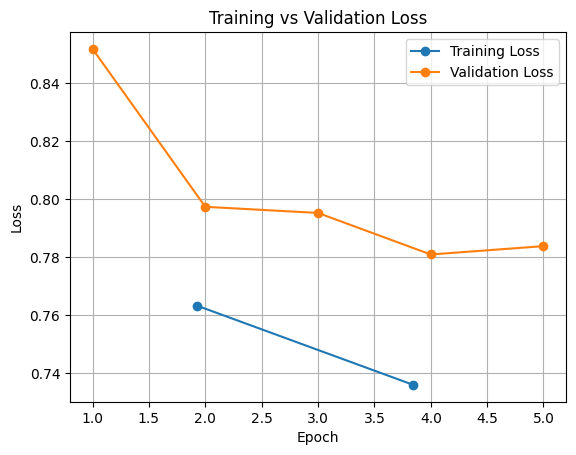

In [ ]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [ ]:
# evaluate finetuned model
results = trainer.evaluate()
results

{'eval_loss': 0.7838097810745239,
 'eval_accuracy': 0.7564946725727284,
 'eval_f1_macro': 0.6062325686831646,
 'eval_f1_weighted': 0.7488666037791097,
 'eval_runtime': 3.7952,
 'eval_samples_per_second': 468.487,
 'eval_steps_per_second': 14.756,
 'epoch': 5.0}

### Save Model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser")
tokenizer.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser")

trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nalyser/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...nalyser/model.safetensors:   9%|9         | 40.0MB /  443MB            

CommitInfo(commit_url='https://huggingface.co/amysp/latin-morphological-analyser/commit/63d1d418d728ab60fd872709a65cfc3ddbb4d550', commit_message='End of training', commit_description='', oid='63d1d418d728ab60fd872709a65cfc3ddbb4d550', pr_url=None, repo_url=RepoUrl('https://huggingface.co/amysp/latin-morphological-analyser', endpoint='https://huggingface.co', repo_type='model', repo_id='amysp/latin-morphological-analyser'), pr_revision=None, pr_num=None)

## **Evaluation**

In [ ]:
# load final model and tokenizer
MODEL_PATH = "/content/drive/MyDrive/FYP/morphological_analyser"

model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
# evaluate model on test set
trainer.evaluate(test_dataset)

{'eval_loss': 0.7688625454902649,
 'eval_model_preparation_time': 0.0032,
 'eval_accuracy': 0.7608841259209645,
 'eval_f1_macro': 0.6225596536021429,
 'eval_f1_weighted': 0.7536881489013159,
 'eval_runtime': 13.9212,
 'eval_samples_per_second': 127.719,
 'eval_steps_per_second': 16.019}

### Confusion Matrix

In [ ]:
# get predictions on test set
pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids

labels_flat = np.array(labels).flatten()
preds_flat  = np.array(preds).flatten()

mask = labels_flat != -100
filtered_labels = labels_flat[mask]
filtered_preds  = preds_flat[mask]

In [ ]:
print(cm.shape)        # is it (22, 22) or (23, 23)?
print(len(label_names))

(22, 22)
23


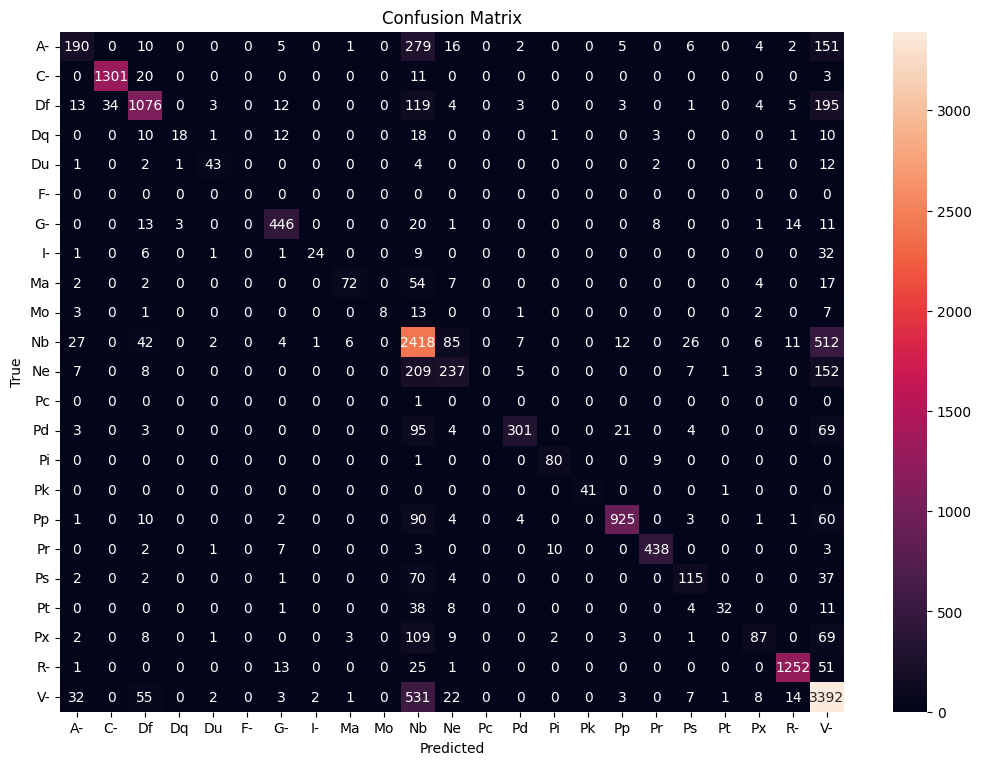

In [ ]:
# plot confusion matrix

# create confusion matrix
cm = confusion_matrix(
    filtered_labels,
    filtered_preds,
    labels=list(range(len(id2label)))
)

label_names = [id2label[i] for i in range(len(id2label))]

n = len(label_names)
fig, ax = plt.subplots(figsize=(14,10))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=label_names,
            yticklabels=label_names,
            ax=ax)


ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Confusion Matrix")
plt.subplots_adjust(left=0.2, bottom=0.2)
plt.show()

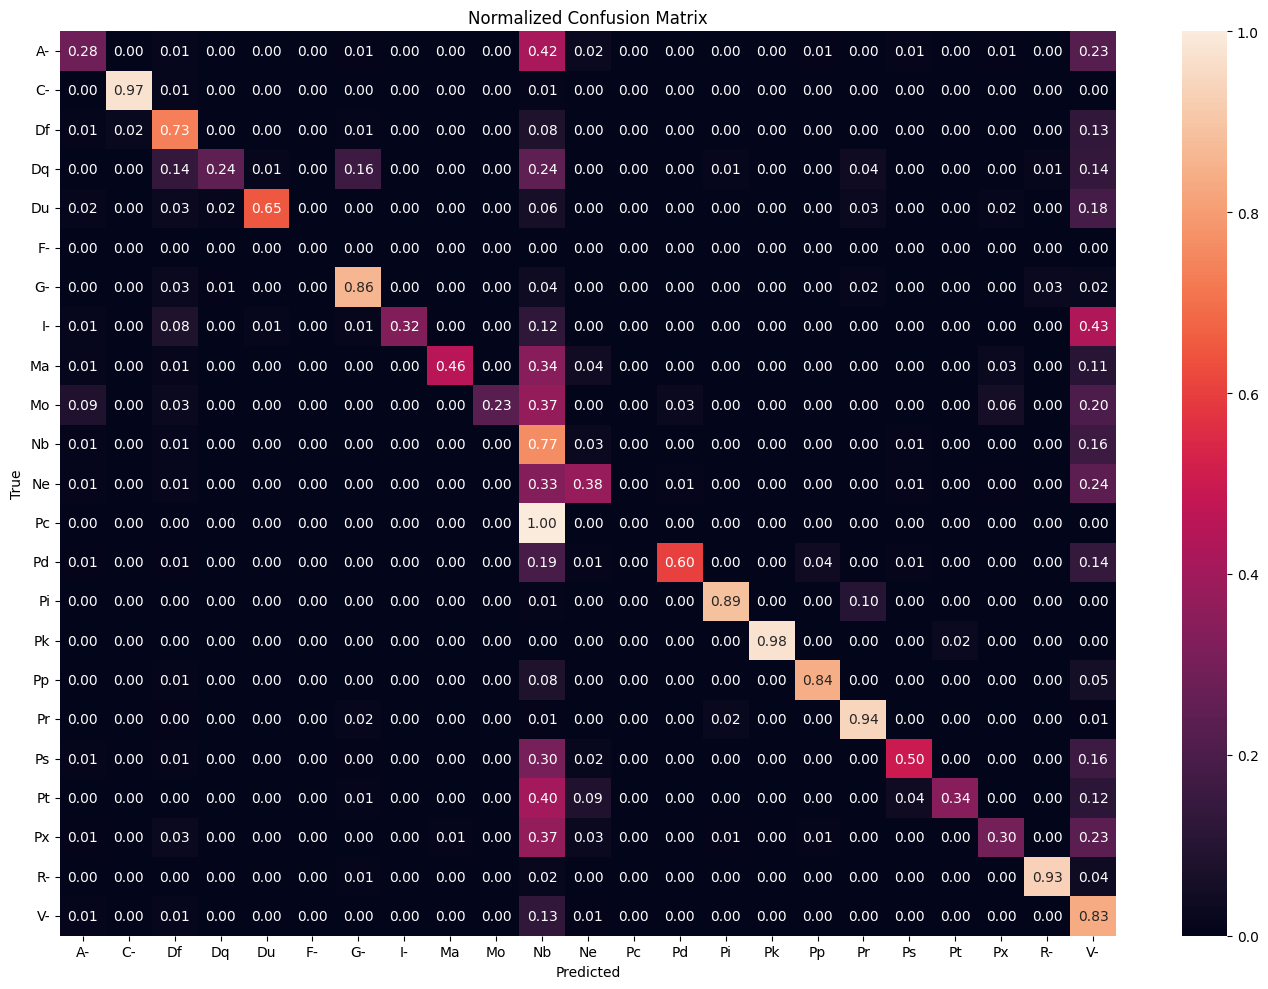

In [ ]:
# normalised confusion matrix
cm_norm = confusion_matrix(
    filtered_labels,
    filtered_preds,
    labels=list(range(len(id2label))),
    normalize='true'
)

plt.figure(figsize=(14,10))
sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.yticks(rotation=0)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

### Classification Report

In [ ]:
# classification report
report = classification_report(
      filtered_labels,
      filtered_preds,
      labels=list(range(len(id2label))),
      target_names=[id2label[i] for i in range(len(id2label))],
      zero_division=0
    )

print(report)

              precision    recall  f1-score   support

          A-       0.67      0.28      0.40       671
          C-       0.97      0.97      0.97      1335
          Df       0.85      0.73      0.78      1472
          Dq       0.82      0.24      0.38        74
          Du       0.80      0.65      0.72        66
          F-       0.00      0.00      0.00         0
          G-       0.88      0.86      0.87       517
          I-       0.89      0.32      0.48        74
          Ma       0.87      0.46      0.60       158
          Mo       1.00      0.23      0.37        35
          Nb       0.59      0.77      0.66      3159
          Ne       0.59      0.38      0.46       629
          Pc       0.00      0.00      0.00         1
          Pd       0.93      0.60      0.73       500
          Pi       0.86      0.89      0.87        90
          Pk       1.00      0.98      0.99        42
          Pp       0.95      0.84      0.89      1101
          Pr       0.95    